این قسمت از پروژه مربوط به استخراج نظرات سایت **`باسلام`** است.  

🚀 Lets Go To WebScraping **`Basalam.com`**

In [137]:
#وارد کردن کتابخانه‌های مورد نیاز 
import sys
import os
import re
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from IPython.display import display, HTML

def jup_msg(text: str):
    display(HTML(f"<div style='padding:6px 0;font-size:14px'>{text}</div>"))

In [138]:
# تنظیمات و مسیر خروجی (فقط مسیر ذخیره تغییر کرد) 
MAIN_PAGE_URL = "https://basalam.com/razmishop/product/7005960"
OUTPUT_CSV = "data/basalam/comments.csv"

STEP_PIXELS = 650
MAX_STEPS = 200
WAIT_AFTER_SCROLL = 3.0
WAIT_FOR_STYLE_TIMEOUT = 12


In [139]:
# توابع اولیه / باز کردن مودال و یافتن اسکرولر 
def init_driver(headless=False):
    opts = Options()
    if headless:
        opts.add_argument("--headless=new")
        opts.add_argument("--disable-gpu")
    opts.add_argument("--window-size=1280,1024")
    return webdriver.Chrome(options=opts)

def open_comments_modal(driver, url):
    jup_msg("🔍 باز کردن صفحه محصول...")
    driver.get(url)
    time.sleep(3)
    btn = WebDriverWait(driver, 20).until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(., 'تجربه خریدها')]"))
    )
    driver.execute_script("arguments[0].click();", btn)
    jup_msg("✅ روی دکمه 'تجربه خریدها' کلیک شد.")
    modal = WebDriverWait(driver, 20).until(
        EC.presence_of_element_located((By.CLASS_NAME, "bs-modal__content"))
    )
    jup_msg("✅ مودال نظرات باز شد.")
    comments_section = WebDriverWait(modal, 20).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "div.bs-box.GSBwLT"))
    )
    jup_msg("✅ بخش نظرات داخل مودال پیدا شد.")
    return comments_section

def find_scroll_element(comments_section):
    candidates = comments_section.find_elements(By.CSS_SELECTOR, 'div[data-testid="virtuoso-scroller"]')
    if candidates:
        return candidates[0]
    all_divs = comments_section.find_elements(By.TAG_NAME, "div")
    for d in all_divs:
        style = (d.get_attribute("style") or "")
        if "overflow-y" in style or "padding-top" in style:
            return d
    raise RuntimeError("اسکرول دیو پیدا نشد.")


In [140]:
# کمک‌توابع برای خواندن padding و جمع‌آوری نظرات
def get_padding_top_from_element(el):
    style = el.get_attribute("style") or ""
    m = re.search(r'padding-top\s*:\s*([0-9]+)\s*px', style)
    if m:
        return int(m.group(1))
    try:
        first_child = el.find_element(By.XPATH, "./*")
        style2 = first_child.get_attribute("style") or ""
        m2 = re.search(r'padding-top\s*:\s*([0-9]+)\s*px', style2)
        if m2:
            return int(m2.group(1))
    except:
        pass
    return None

def wait_for_padding_increase(scroll_el, prev_padding, timeout=WAIT_FOR_STYLE_TIMEOUT):
    start = time.time()
    while time.time() - start < timeout:
        cur = get_padding_top_from_element(scroll_el)
        if cur is not None and prev_padding is not None and cur > prev_padding:
            return cur
        if cur is not None and prev_padding is None:
            return cur
        time.sleep(1.5)
    return None

def collect_new_reviews(comments_section, seen_ids):
    review_elements = comments_section.find_elements(By.CSS_SELECTOR, "div.eN63l8._9ltxo8")
    new_items = []
    for r in review_elements:
        rid = r.get_attribute("id") or r.get_attribute("data-item-index") or r.get_attribute("data-index") or None
        if not rid:
            rid = f"noid-{hash(r.text) & 0xfffffff}"
        if rid in seen_ids:
            continue
        seen_ids.add(rid)
        try:
            name = r.find_element(By.CLASS_NAME, "Rqze5j").text.strip()
        except:
            name = ""
        try:
            date = r.find_element(By.CLASS_NAME, "eN4XZm").text.strip()
        except:
            date = ""
        try:
            stars = len(r.find_elements(By.CLASS_NAME, "bs-rating__star--active"))
        except:
            stars = 0
        try:
            text = r.find_element(By.CLASS_NAME, "nkJy9o").text.strip()
        except:
            text = ""
        new_items.append({
            "id": rid,
            "نام کاربر": name,
            "تاریخ": date,
            "امتیاز": stars,
            "متن نظر": text
        })
    return new_items, len(review_elements)


In [141]:
# تابع اصلی اسکرول و جمع‌آوری نظرات (خروجی‌ها کوتاه و مخصوص Jupyter)
WAIT_AFTER_SCROLL = 0.1
WAIT_FOR_STYLE_TIMEOUT = 1.0

def scrape_all_reviews(driver, comments_section, step_pixels=STEP_PIXELS):
    scroll_el = find_scroll_element(comments_section)
    jup_msg("✅ اسکرولر پیدا شد — شروع اسکرول مرحله‌ای")

    seen = set()
    all_reviews = []
    no_new_count = 0

    initial_new, total_now = collect_new_reviews(comments_section, seen)
    if initial_new:
        jup_msg(f"⏺ ابتدا {len(initial_new)} مورد جدید یافت شد.")
        all_reviews.extend(initial_new)
    else:
        jup_msg(f"⏺ ابتدا مورد جدیدی در DOM یافت نشد (شمار: {total_now}).")

    prev_padding = get_padding_top_from_element(scroll_el)

    for step in range(1, MAX_STEPS + 1):
        driver.execute_script(
            "arguments[0].scrollTop = arguments[0].scrollTop + arguments[1];",
            scroll_el, step_pixels
        )
        time.sleep(0.5)

        new_padding = wait_for_padding_increase(scroll_el, prev_padding, timeout=3)
        if new_padding is None:
            # از اعلام جزئیات تغییر padding صرف‌نظر می‌کنیم (مطابق درخواست)
            driver.execute_script(
                "arguments[0].scrollTop = arguments[0].scrollTop + arguments[1];",
                scroll_el, step_pixels
            )
            time.sleep(1)
            new_padding = get_padding_top_from_element(scroll_el)

        prev_padding = new_padding if new_padding is not None else prev_padding
        time.sleep(1)

        new_items, total_now = collect_new_reviews(comments_section, seen)
        if new_items:
            all_reviews.extend(new_items)
            no_new_count = 0
            jup_msg(f"➕ {len(new_items)} نظر جدید — کل: {len(all_reviews)}")
        else:
            no_new_count += 1
            if no_new_count >= 2:
                jup_msg("⏹ دو بار متوالی مورد جدیدی پیدا نشد. توقف اسکرول.")
                break

    jup_msg("✅ پایان اسکرول مرحله‌ای.")
    return pd.DataFrame(all_reviews)


In [142]:
#main و ذخیره‌سازی در data/basalam
def main():
    out_dir = os.path.dirname(OUTPUT_CSV)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    driver = init_driver(headless=False)
    try:
        comments_section = open_comments_modal(driver, MAIN_PAGE_URL)
        df = scrape_all_reviews(driver, comments_section, step_pixels=STEP_PIXELS)
        df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
        jup_msg(f"💾 فایل ذخیره شد در: <code>{OUTPUT_CSV}</code> — تعداد: {len(df)}")
    finally:
        driver.quit()
main()


## مرحله بعد: پردازش نظرات ✍️💬

اینجا متن‌ها را پاک‌سازی می‌کنیم، کلمات را ریشه‌یابی می‌کنیم و متن را آماده می‌کنیم تا بتوانیم بهتر تحلیل کنیم.

🚀 Let's go to **Text Preprocessing!**

### 📚 وارد کردن کتابخانه‌های مورد نیاز

در این پروژه برای **پردازش دیدگاه‌های فارسی و تحلیل احساسات** از چند کتابخانه مهم استفاده می‌کنیم:

- `os` 🗂️ مدیریت مسیرها و فایل‌ها  
- `sys` 💻 تنظیمات محیط و خروجی‌ها  
- `re` 🔍 عملیات روی رشته‌ها و پاکسازی متن  
- `string` ✏️ مدیریت و حذف کاراکترهای اضافی  
- `pandas` 📊 بارگذاری، مدیریت و تحلیل داده‌ها در قالب DataFrame  
- `matplotlib.pyplot` 📈 مصورسازی داده‌ها و نمودارهای آماری  
- `seaborn` 🎨 زیباسازی نمودارها و تحلیل توزیع‌ها  
- `collections.Counter` 📑 شمارش تکرار کلمات و تحلیل توزیع آنها  
- `hazm` 📝 پردازش زبان طبیعی فارسی، شامل **Normalizing** و **Tokenization**  
- `wordcloud` ☁️ ساخت و نمایش **ابرکلمات (WordCloud)**  
- `arabic_reshaper` 🔄 راست‌چین کردن متن فارسی  
- `bidi.algorithm.get_display` ↔️ نمایش صحیح متن فارسی در WordCloud  
- `sklearn` 🧠 ابزارهای **TF-IDF** و تقسیم‌بندی داده‌ها برای مدل‌سازی  
- `imblearn.SMOTE` ⚖️ متوازن‌سازی داده‌های نامتوازن برای مدل‌سازی  

> 🔹 این کتابخانه‌ها پایه و اساس پردازش متن فارسی، تحلیل احساسات و مصورسازی نتایج در این پروژه هستند.


In [143]:
import os, re, string
import pandas as pd
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from hazm import Normalizer, WordTokenizer
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


### 🗂️ بارگذاری و بررسی داده‌ها

در این مرحله داده‌ها را از فایل CSV بارگذاری می‌کنیم و بررسی اولیه‌ای روی ستون‌ها و محتوا انجام می‌دهیم:  

- `os.path.join` 🔗 مسیر فایل CSV را به صورت ایمن می‌سازد  
- `pd.read_csv` 📊 داده‌ها را در قالب DataFrame می‌خواند  
- `df.head()` 👀 نمایش اولین سطرهای داده برای بررسی سریع  
- بررسی وجود فایل ❌ اگر فایل پیدا نشد، خطا می‌دهد


In [144]:
# مسیر فایل خروجی نسبت به پروژه
BASE_DIR = os.getcwd()  # مسیر فعلی پروژه
csv_file = os.path.join(BASE_DIR, "data", "basalam", "comments.csv")

# بررسی وجود فایل
if not os.path.exists(csv_file):
    raise FileNotFoundError(f"❌ فایل {csv_file} پیدا نشد")

# بارگذاری داده‌ها
df = pd.read_csv(csv_file, encoding="utf-8-sig")
df = df[["نام کاربر", "امتیاز", "متن نظر"]]
df.columns = ["name", "stars", "comment"]

# نمایش 5 سطر اول و ستون‌ها
print("ستون‌های فایل:")
print(df.columns)
df.head()


ستون‌های فایل:
Index(['name', 'stars', 'comment'], dtype='object')


,name,stars,comment
0,دوست باسلامی,5,برای کسی سفارش داده بودم که خدارو شکر راضی هست...
1,امیر محمد صالحی,5,از فروشنده ممنونم خیلی زود بدستم رسید وبسیار ب...
2,دوست باسلامی,4,زود و با بسته بندی خوب به دستم رسید و کیفیت خو...
3,ابوالفضل کلهر,5,ظاهر زیبایی داره و فعلا هم کارکرد خوبی داشته
4,مهران رجعتی,5,عالی بود تشکر از غرفه دار محترم


### ⭐ مرحله 2: حذف امتیاز ۳ و برچسب‌گذاری احساسات

در این مرحله، داده‌ها را به دو دسته **مثبت** و **منفی** تقسیم می‌کنیم:  

- ابتدا دیدگاه‌هایی که امتیاز **۳ ستاره** دارند را حذف می‌کنیم، چون معمولاً خنثی هستند.  
- سپس ستون جدیدی به نام `sentiment` اضافه می‌کنیم:  
  - `1` برای دیدگاه‌های مثبت (امتیاز ۴ یا ۵)  
  - `0` برای دیدگاه‌های منفی (امتیاز ۱ یا ۲)  


In [145]:
# حذف دیدگاه‌های با امتیاز 3
df = df[df['stars'] != 3]

# برچسب‌گذاری احساسات
df['sentiment'] = df['stars'].apply(lambda x: 1 if x >= 4 else 0)

# نمایش 5 سطر اول برای بررسی
df.head()

,name,stars,comment,sentiment
0,دوست باسلامی,5,برای کسی سفارش داده بودم که خدارو شکر راضی هست...,1
1,امیر محمد صالحی,5,از فروشنده ممنونم خیلی زود بدستم رسید وبسیار ب...,1
2,دوست باسلامی,4,زود و با بسته بندی خوب به دستم رسید و کیفیت خو...,1
3,ابوالفضل کلهر,5,ظاهر زیبایی داره و فعلا هم کارکرد خوبی داشته,1
4,مهران رجعتی,5,عالی بود تشکر از غرفه دار محترم,1


### 📊 مرحله 3: تحلیل داده‌ها (EDA) اولیه

در این مرحله داده‌ها را به صورت **آماری و تصویری** بررسی می‌کنیم:  

- طول دیدگاه‌ها (تعداد کلمات) را محاسبه می‌کنیم.  
- میانگین، کوتاه‌ترین و بلندترین دیدگاه‌ها را بررسی می‌کنیم.  
- توزیع احساسات را با نمودار **ستونی** نمایش می‌دهیم.  
- برای نمایش درست متن فارسی در نمودار، از کتابخانه `arabic_reshaper` و `bidi.algorithm` استفاده می‌کنیم.

میانگین طول دیدگاه‌ها: 10.35 📝
کوتاه‌ترین: 1 کلمه ✂️
کوتاه‌ترین کلمه: و ✂️
بلندترین: 54 کلمه 📏
سه نمونه از بلندترین کلمات: ['بودوواقعابایدازغرفه', 'مجددبراروزمادرهدیه', 'بودهنوزاستفاده'] 📏


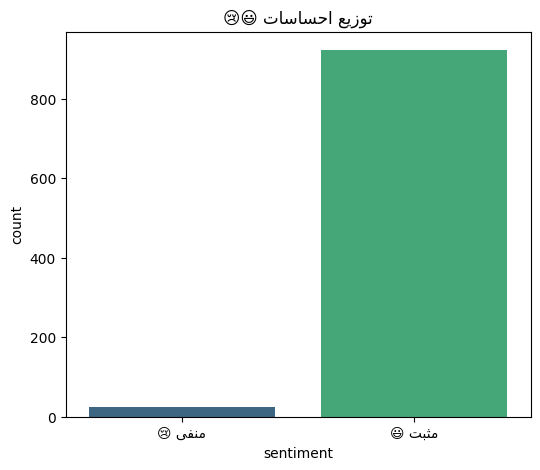

In [146]:
# محاسبه طول دیدگاه‌ها
df['comment_length'] = df['comment'].apply(lambda x: len(str(x).split()))
print(f"میانگین طول دیدگاه‌ها: {df['comment_length'].mean():.2f} 📝")



# استخراج تمام کلمات با حذف توقف‌کلمات و غیرحروفی
all_words = [
    word for comment in df['comment'] 
    for word in str(comment).split() 
    if word.isalpha()  # فقط کلمات حاوی حروف
]

# کوتاه‌ترین کلمه واقعی
shortest_word = min(all_words, key=len)
print(f"کوتاه‌ترین: {df['comment_length'].min()} کلمه ✂️")
print(f"کوتاه‌ترین کلمه: {shortest_word} ✂️")

# سه کلمه بلندترین نمونه
longest_words = sorted(all_words, key=len, reverse=True)[:3]
print(f"بلندترین: {df['comment_length'].max()} کلمه 📏")
print(f"سه نمونه از بلندترین کلمات: {longest_words} 📏")


# تابع برای راست‌چین کردن متن فارسی
def fa_text(text):
    try:
        return get_display(arabic_reshaper.reshape(text))
    except:
        return text

# نمایش توزیع احساسات
plt.figure(figsize=(6,5))
sns.countplot(x='sentiment', data=df, palette="viridis", hue='sentiment', legend=False)
plt.title(fa_text("توزیع احساسات 😃😢"))
plt.xticks([0,1], [fa_text("منفی 😢"), fa_text("مثبت 😃")])
plt.savefig("figures/basalam/Sentiment_distribution_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### 📊 توزیع درصدی احساسات با نمودار دایره‌ای

در این بخش، از نمودار دایره‌ای استفاده می‌کنیم تا سهم **دیدگاه‌های مثبت** و **منفی** را به درصد نشان دهیم. این نمودار به ما کمک می‌کند تا به‌صورت بصری توزیع احساسات را ببینیم و علاوه بر آن، تعداد دقیق هر دسته را هم چاپ خواهیم کرد.


تعداد دیدگاه‌ها بر اساس احساسات:
منفی 😢: 24 دیدگاه
مثبت 😃: 923 دیدگاه


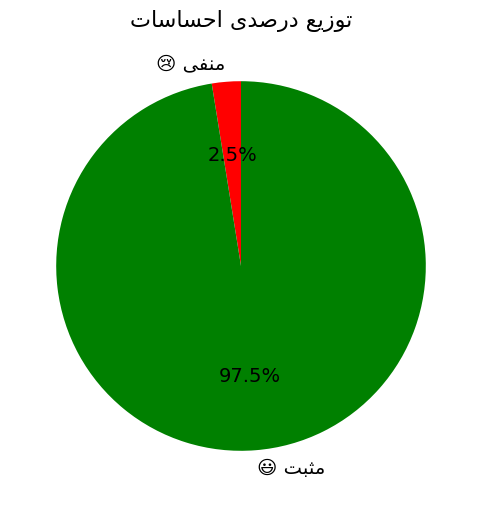

In [147]:
# تعداد هر دسته
sentiment_counts = df['sentiment'].value_counts().reindex([0,1])  # اطمینان از ترتیب [منفی، مثبت]

# نمایش تعداد دقیق
print("تعداد دیدگاه‌ها بر اساس احساسات:")
print(f"منفی 😢: {sentiment_counts[0]} دیدگاه")
print(f"مثبت 😃: {sentiment_counts[1]} دیدگاه")

# نمودار دایره‌ای
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=[fa_text("منفی 😢"), fa_text("مثبت 😃")],
        autopct='%1.1f%%', colors=['red', 'green'], startangle=90, textprops={'fontsize':14})
plt.title(fa_text("توزیع درصدی احساسات"), fontsize=16)
plt.savefig("figures/basalam/Sentiment_distribution2_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### 🧹 پاکسازی و پیش‌پردازش متن‌ها

در این بخش، متن دیدگاه‌ها را برای پردازش‌های بعدی آماده می‌کنیم:

- حذف نویسه‌های غیرحروفی و علائم نگارشی ✂️  
- تبدیل اعداد به فضای خالی 🔢  
- نرمال‌سازی حروف فارسی 📝  
- حذف فاصله‌های اضافی و ایجاد توکن‌ها  
- آماده‌سازی متن‌ها برای WordCloud و تحلیل کلمات


In [148]:
# ایجاد نرمالایزر
normalizer = Normalizer()

def preprocess_text_clean(text):
    if not isinstance(text, str):
        return ""
    # نرمال‌سازی متن
    text = normalizer.normalize(text)
    # حذف تمام علائم نگارشی و نویسه‌های غیرحروفی
    text = re.sub(r"[^\w\sآ-ی]", " ", text)
    # حذف اعداد فارسی و انگلیسی
    text = re.sub(r"[0-9۰-۹]+", " ", text)
    # حذف فاصله‌های اضافی
    text = re.sub(r"\s+", " ", text).strip()
    return text

# اعمال پیش‌پردازش دقیق روی ستون comment
df['processed_comment'] = df['comment'].apply(preprocess_text_clean)

# نمایش چند نمونه برای بررسی
df[['comment', 'processed_comment']].head(5)

,comment,processed_comment
0,برای کسی سفارش داده بودم که خدارو شکر راضی هست...,برای کسی سفارش داده بودم که خدارو شکر راضی هست...
1,از فروشنده ممنونم خیلی زود بدستم رسید وبسیار ب...,از فروشنده ممنونم خیلی زود بدستم رسید وبسیار ب...
2,زود و با بسته بندی خوب به دستم رسید و کیفیت خو...,زود و با بسته بندی خوب به دستم رسید و کیفیت خو...
3,ظاهر زیبایی داره و فعلا هم کارکرد خوبی داشته,ظاهر زیبایی داره و فعلا هم کارکرد خوبی داشته
4,عالی بود تشکر از غرفه دار محترم,عالی بود تشکر از غرفه دار محترم


### 📊 تحلیل طول دیدگاه‌ها بر اساس احساسات

در این بخش:

- نمودار پراکندگی طول دیدگاه‌ها برای مثبت و منفی
- بررسی اینکه دیدگاه‌های طولانی‌تر بیشتر مثبت‌اند یا منفی
- خروجی فارسی و راست‌چین


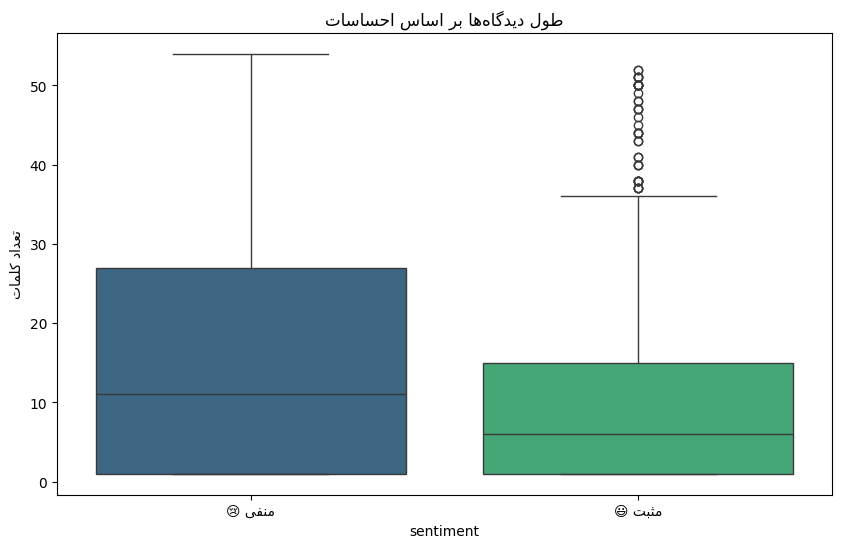

میانگین طول دیدگاه‌ها:
sentiment
منفی    17.041667
مثبت    10.178765
Name: comment_length, dtype: float64


<Figure size 640x480 with 0 Axes>

In [149]:
# تحلیل طول دیدگاه‌ها بر اساس احساسات
plt.figure(figsize=(10,6))
sns.boxplot(x='sentiment', y='comment_length', data=df, palette='viridis')
plt.xticks([0,1], [fa_text("منفی 😢"), fa_text("مثبت 😃")])
plt.ylabel(fa_text("تعداد کلمات"))
plt.title(fa_text("طول دیدگاه‌ها بر اساس احساسات"))
plt.show()

# میانگین طول دیدگاه‌ها بر اساس احساسات
length_stats = df.groupby('sentiment')['comment_length'].mean().rename({0:"منفی", 1:"مثبت"})
plt.savefig("figures/basalam/Length_comments_sentiment_plot.png", dpi=300, bbox_inches="tight")
print(f"میانگین طول دیدگاه‌ها:\n{length_stats}")

### 🧹 مرحله 4: پاکسازی و پیش‌پردازش متن‌ها

در این بخش، متن دیدگاه‌ها را برای پردازش‌های بعدی آماده می‌کنیم:

- حذف نویسه‌های غیرحروفی و علائم نگارشی ✂️
- تبدیل اعداد به فضای خالی 🔢
- نرمال‌سازی حروف فارسی 📝
- حذف فاصله‌های اضافی و ایجاد توکن‌ها
- آماده‌سازی متن‌ها برای WordCloud و تحلیل کلمات 🔍


In [150]:
# لیست کلمات توقف فارسی + کلمات اضافی
persian_stopwords = list(set([
    'و', 'در', 'به', 'از', 'که', 'می', 'با', 'برای', 'این', 'آن', 'است', 'ها', 'یک', 'بر', 'را', 'شود',
    'هر', 'تا', 'او', 'ما', 'شما', 'آنها', 'هم', 'نیز', 'اما', 'اگر', 'جز', 'نه', 'یا', 'دیگر',
    'مثل', 'فقط', 'پس', 'چون', 'کنید', 'کنند', 'بود', 'شد', 'آنچه', 'یکی', 'ترین',
    'هرگز', 'همه', 'باید', 'نزدیک', 'همین', 'یعنی', 'وقتی', 'خیلی', 'چند', 'اگرچه', 'ولی', 'اند',
    'رو', 'شاید', 'اینه', 'شده', 'این', 'اون', 'هست', 'میباشد', 'می‌باشد', 'همچنین', 'البته'
]))

# لیست کامل علائم نگارشی فارسی و انگلیسی
all_punctuations = string.punctuation + "،؛؟!«»…“”–—ـ"

# نرمال‌سازی با Hazm
normalizer = Normalizer()

# پیش‌پردازش متن
# حذف ایموجی‌ها
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F1E0-\U0001F1FF"  # پرچم‌ها
        "\U0001F300-\U0001F5FF"  # نمادهای عمومی
        "\U0001F600-\U0001F64F"  # شکلک‌ها
        "\U0001F680-\U0001F6FF"  # حمل و نقل
        "\U0001F700-\U0001F77F"  # سمبل‌های دیگر
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\u2600-\u26FF"          # سمبل‌های عمومی
        "\u2700-\u27BF"          # سمبل‌های دیگر
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)


def preprocess_text(text, for_wordcloud=False):
    if not isinstance(text, str):
        return ""
    text = normalizer.normalize(text)
    text = remove_emojis(text)                        # حذف جامع ایموجی‌ها
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  # حذف علائم
    text = re.sub(r"\d+", " ", text)                                # حذف عدد
    text = re.sub(r"\s+", " ", text).strip()                        # حذف فاصله اضافه
    tokens = text.split()
    filtered_tokens = [w for w in tokens if w not in persian_stopwords]
    return " ".join(filtered_tokens)


# اعمال پیش‌پردازش روی ستون دیدگاه‌ها
df['processed_comment'] = df['comment'].apply(preprocess_text)

# نمایش 5 دیدگاه اول پس از پاکسازی و پیش‌پردازش
print("✍️💬۵ دیدگاه اول پس از پاکسازی:")
print(df['processed_comment'].head(5))
# ذخیره فایل cleaned_reviews.csv
save_dir = os.path.join("data", "Basalam")
os.makedirs(save_dir, exist_ok=True)

cleaned_csv_file = os.path.join(save_dir, "cleaned_reviews.csv")
df.to_csv(cleaned_csv_file, index=False, encoding="utf-8-sig")
print(f"✅ نظرات پاکسازی شده در فایل {cleaned_csv_file} ذخیره شد 📝")


✍️💬۵ دیدگاه اول پس از پاکسازی:
0    کسی سفارش داده بودم خدارو شکر راضی هستند کار ب...
1    فروشنده ممنونم زود بدستم رسید وبسیار بسته بندی...
2    زود بسته بندی خوب دستم رسید کیفیت خوبی داره از...
3              ظاهر زیبایی داره فعلا کارکرد خوبی داشته
4                             عالی تشکر غرفه دار محترم
Name: processed_comment, dtype: object
✅ نظرات پاکسازی شده در فایل data\Basalam\cleaned_reviews.csv ذخیره شد 📝


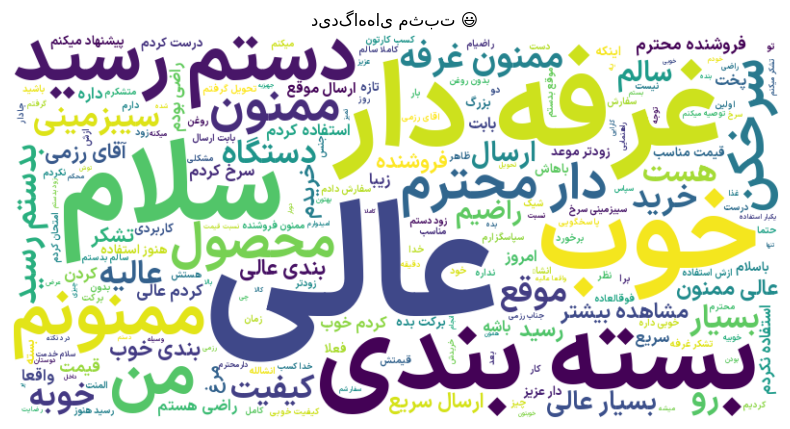

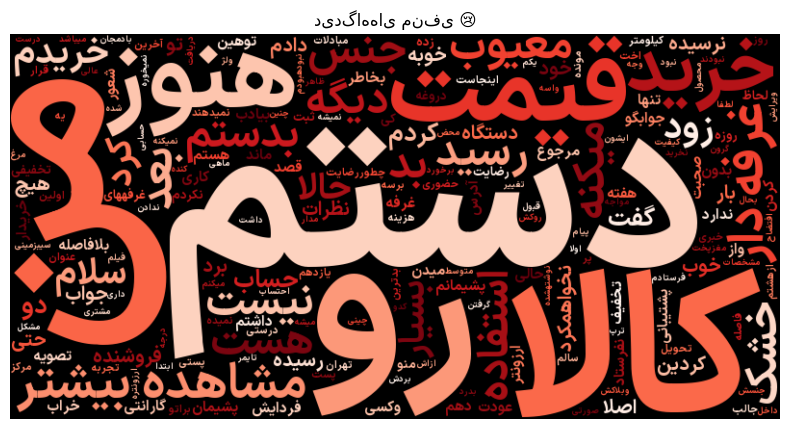

📝 پرکاربردترین کلمات مثبت: [('عالی', 351), ('رسید', 165), ('خوب', 147), ('ممنون', 145), ('غرفه', 127), ('دار', 125), ('سلام', 109), ('دستم', 107), ('بسته', 103), ('بندی', 99), ('کردم', 93), ('محترم', 90), ('ارسال', 85), ('بسیار', 74), ('موقع', 70), ('من', 69), ('ممنونم', 68), ('فروشنده', 62), ('سیب\u200cزمینی', 58), ('محصول', 57)]
📝 پرکاربردترین کلمات منفی: [('دستم', 6), ('من', 5), ('غرفه', 5), ('رو', 4), ('قیمت', 4), ('دار', 4), ('خرید', 4), ('کالا', 4), ('مشاهده', 4), ('بیشتر', 4), ('هنوز', 4), ('هست', 3), ('بعد', 3), ('استفاده', 3), ('بدستم', 3), ('رسید', 3), ('بد', 3), ('جنس', 3), ('خشک', 3), ('دیگه', 3)]


In [151]:
mne = Normalizer()
mte = WordTokenizer()

persian_stopwords = ['و', 'در', 'به', 'از', 'که', 'می', 'با', 'برای', 'این', 'آن', 'است', 'ها', 'یک', 'بر', 'را', 'شود',
                     'هر', 'تا', 'او', 'ما', 'شما', 'آنها', 'هم', 'نیز', 'اما', 'اگر', 'جز', 'نه', 'یا', 'اما', 'دیگر',
                     'مثل', 'فقط', 'پس', 'چون', 'کنید', 'کنند', 'بود', 'شد', 'است', 'آنچه', 'یکی', 'ترین', 'شما', 'او',
                     'هرگز', 'همه', 'باید', 'نزدیک', 'همین', 'یعنی', 'وقتی', 'خیلی', 'چند', 'اگرچه', 'ولی', 'اند']

def simplepreprocess(text):
    if not isinstance(text,str):
        return ""
    text = mne.normalize(text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)
    text = re.sub(r"\d+", '', text)
    text = re.sub(r"\s+", ' ', text).strip()
    tokens = mte.tokenize(text)
    filtered_tokens = [word for word in tokens if word not in persian_stopwords and len(word) > 1]
    return " ".join(filtered_tokens)

df['cleaned_comment_for_eda'] = df['comment'].apply(simplepreprocess)

pos = " ".join(df[df['sentiment'] == 1]['cleaned_comment_for_eda'].dropna())
neg = " ".join(df[df['sentiment'] == 0]['cleaned_comment_for_eda'].dropna())

font = os.path.join("files", "font.ttf")

def reshape_fa_text_for_wordcloud_safe(text):
    text = re.sub(r'[^آ-ی\s]', '', text)
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# WordCloud دیدگاه‌های مثبت
if pos:
    reshaped_positive_text = reshape_fa_text_for_wordcloud_safe(pos)
    wordcloudpos = WordCloud(
        font_path=font,
        width=800,
        height=400,
        background_color='white'
    ).generate(reshaped_positive_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloudpos, interpolation='bilinear')
    plt.axis('off')
    plt.title("دیدگاه‌های مثبت 😃")
    plt.savefig("figures/basalam/Positive_comments_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print('❌ دیدگاه مثبت موجود نیست')

# WordCloud دیدگاه‌های منفی
if neg:
    reshaped_negative_text = reshape_fa_text_for_wordcloud_safe(neg)  # ❌ اصلاح شد: pos -> neg
    wordcloudneg = WordCloud(
        font_path=font,
        width=800,
        height=400,
        background_color='black',
        colormap='Reds'
    ).generate(reshaped_negative_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloudneg, interpolation='bilinear')
    plt.axis('off')
    plt.title("دیدگاه‌های منفی 😢")
    plt.savefig("figures/basalam/Negative_comments_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print('❌ دیدگاه منفی موجود نیست')

# پرکاربردترین کلمات
def top_words(text, n=20):
    words = text.split()
    return Counter(words).most_common(n)

print("📝 پرکاربردترین کلمات مثبت:", top_words(pos))
print("📝 پرکاربردترین کلمات منفی:", top_words(neg))

## مرحله ۳: پیش‌پردازش متن‌های فارسی 📝🧹

در این مرحله، متن‌های نظرات را پاک‌سازی می‌کنیم، کلمات را ریشه‌یابی و نرمالایز می‌کنیم، و توقف‌کلمات فارسی را حذف می‌کنیم تا داده‌ها برای تحلیل و مدل‌سازی آماده شوند.  

✨ کارهایی که انجام می‌دهیم:  
- نرمال‌سازی متن با **`Normalize`** 🔄  
- توکنایز کردن متن با **`Tokenizer`** 🧩  
- ریشه‌یابی کلمات با **`Stemmer`** 🌱  
- حذف توقف‌کلمات فارسی ❌  
- حذف ردیف‌های خالی پس از پردازش 🗑️  

🚀 Ready for **`analysis and model training`**!


### 📚 وارد کردن کتابخانه‌های مورد نیاز

در این فاز، کتابخانه‌های اصلی برای **پردازش متن فارسی و تحلیل احساسات** را وارد می‌کنیم:

- `pandas` 📊 بارگذاری، مدیریت و تحلیل داده‌ها در قالب DataFrame  
- `numpy` 🔢 عملیات عددی و مدیریت آرایه‌ها  
- `matplotlib.pyplot` 📈 مصورسازی داده‌ها و نمودارهای آماری  
- `seaborn` 🎨 زیباسازی نمودارها و تحلیل توزیع‌ها  
- `WordCloud` ☁️ ساخت و نمایش **ابرکلمات (WordCloud)**  
- `hazm` 📝 ابزار پردازش زبان طبیعی فارسی شامل **نرمال‌سازی، توکن‌سازی، ریشه‌یابی و حذف stopwords**  
- `sklearn.model_selection.train_test_split` 🧠 تقسیم داده‌ها به مجموعه آموزش و تست  
- `sklearn.feature_extraction.text.CountVectorizer` و `TfidfVectorizer` 💡 تبدیل متن به بردارهای عددی (Bag-of-Words و TF-IDF)  
- `sklearn.naive_bayes.MultinomialNB` 📊 مدل Naive Bayes برای طبقه‌بندی متن  
- `sklearn.metrics` 🧮 ارزیابی عملکرد مدل (دقت، گزارش طبقه‌بندی، ماتریس سردرگمی)  
- `joblib` 💾 ذخیره و بارگذاری مدل‌های آموزش‌دیده  

> 🔹 این کتابخانه‌ها پایه و اساس **پاک‌سازی، تحلیل، مدل‌سازی و مصورسازی داده‌های متنی فارسی** در این پروژه هستند.

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from hazm import Normalizer, word_tokenize, Stemmer, stopwords_list
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

## بارگذاری داده‌های تمیز شده برای مدل‌سازی 📝

در این بخش، داده‌هایی که در **فاز ۲ تمیز و پیش‌پردازش شده‌اند** را بارگذاری می‌کنیم تا بتوانیم مستقیماً به **مدل‌سازی و تحلیل احساسات** بپردازیم.

📌 مراحل انجام شده:

1. بارگذاری فایل `cleaned_reviews.csv` که شامل ستون‌های:
   - `processed_comment` ✍️ متن پیش‌پردازش شده
   - `sentiment` 😃😢 برچسب احساسات
2. بررسی چند ردیف اول داده‌ها برای اطمینان از صحت پردازش 👀

> 💡 با این کار، زمان اجرای پروژه کاهش می‌یابد و مراحل تکراری پیش‌پردازش دوباره انجام نمی‌شوند.


In [153]:
csv_file = os.path.join("data", "basalam", "cleaned_reviews.csv")
df = pd.read_csv(csv_file, encoding="utf-8-sig")
df.head()

,name,stars,comment,sentiment,comment_length,processed_comment
0,دوست باسلامی,5,برای کسی سفارش داده بودم که خدارو شکر راضی هست...,1,24,کسی سفارش داده بودم خدارو شکر راضی هستند کار ب...
1,امیر محمد صالحی,5,از فروشنده ممنونم خیلی زود بدستم رسید وبسیار ب...,1,16,فروشنده ممنونم زود بدستم رسید وبسیار بسته بندی...
2,دوست باسلامی,4,زود و با بسته بندی خوب به دستم رسید و کیفیت خو...,1,17,زود بسته بندی خوب دستم رسید کیفیت خوبی داره از...
3,ابوالفضل کلهر,5,ظاهر زیبایی داره و فعلا هم کارکرد خوبی داشته,1,9,ظاهر زیبایی داره فعلا کارکرد خوبی داشته
4,مهران رجعتی,5,عالی بود تشکر از غرفه دار محترم,1,7,عالی تشکر غرفه دار محترم


## 🔎 تحلیل اکتشافی داده‌ها (EDA) 📊

در این مرحله، با هدف **درک بهتر ویژگی‌های داده‌ها و توزیع برچسب‌ها**، یک تحلیل اکتشافی انجام می‌دهیم:

📌 مراحل انجام شده:

1. **طول متن‌ها**  
   - محاسبه تعداد کلمات هر متن  
   - رسم هیستوگرام برای مشاهده توزیع طول متن‌ها  

2. **توزیع برچسب احساسات (sentiment)**  
   - تعداد نمونه‌های هر برچسب  
   - نمایش با نمودار میله‌ای  

3. **نمایش ابرکلمات (WordCloud)**  
   - نمایش پرتکرارترین کلمات در کل مجموعه داده  

4. **کلمات پرتکرار (Top Words)**  
   - استخراج ۲۰ کلمه پرکاربرد با استفاده از `CountVectorizer`  
   - نمایش لیست به همراه فراوانی هر کلمه

> 💡 این تحلیل به ما کمک می‌کند تا **ویژگی‌های متنی و تعادل کلاس‌ها** را قبل از مدل‌سازی درک کنیم.

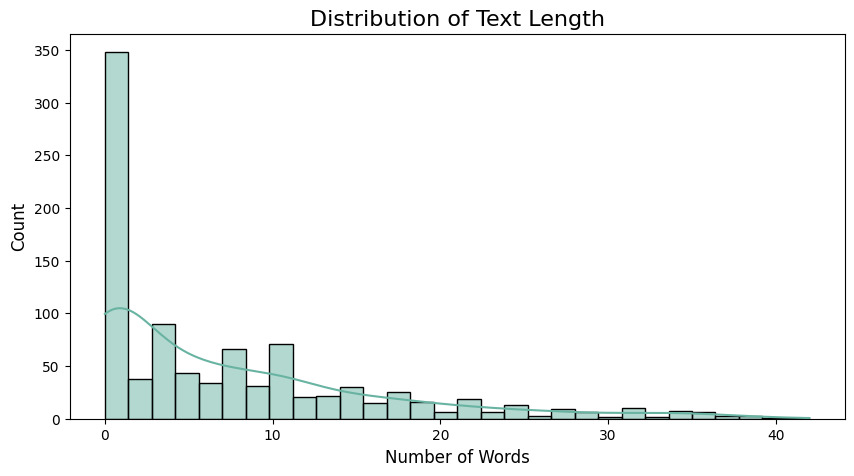

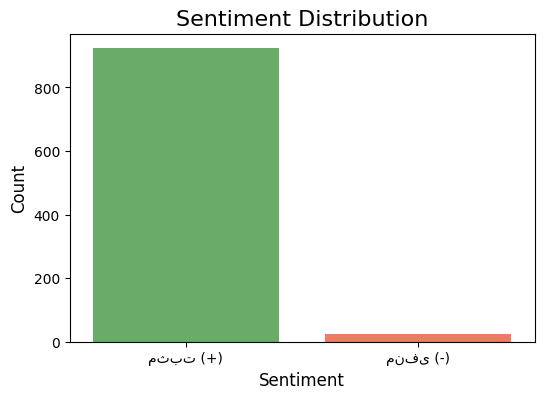

Top 20 words:
عالی: 357
رسید: 170
خوب: 151
ممنون: 146
غرفه: 135
دار: 132
دستم: 113
سلام: 112
بسته: 105
بندی: 101
کردم: 100
سرخ: 95
محترم: 91
ارسال: 86
می: 79
بسیار: 76
من: 74
موقع: 71
ممنونم: 69
فروشنده: 66


In [154]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# جایگزینی NaN با رشته خالی و تبدیل به str
df['processed_comment'] = df['processed_comment'].fillna("").astype(str)

# طول متن
df['text_length'] = df['processed_comment'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=30, kde=True, color="#69b3a2")  # رنگ سبز-آبی
plt.title("Distribution of Text Length", fontsize=16)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig("figures/basalam/Distribution_Text_Length.png", dpi=300, bbox_inches="tight")
plt.show()

# توزیع sentiment با نمایش متن و علامت + و -
plt.figure(figsize=(6,4))
sentiment_labels = {1: "مثبت (+)", 0: "منفی (-)"}
colors = ["#5cb85c", "#ff704d"]  # مثبت: سبز مایل به آبی، منفی: نارنجی-قرمز
sns.countplot(x=df['sentiment'].map(sentiment_labels), palette=colors)
plt.title("Sentiment Distribution", fontsize=16)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

# Top 20 words
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(df['processed_comment'])
sum_words = X_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

print("Top 20 words:")
for word, freq in words_freq[:20]:
    print(f"{word}: {freq}")


## ✂️ تقسیم داده و بردارسازی با TF-IDF

در این بخش، داده‌ها را به **ویژگی‌ها و برچسب‌ها** تقسیم می‌کنیم و متن‌ها را به **بردارهای TF-IDF** تبدیل می‌کنیم.

📌 مراحل انجام شده:

1. تعیین متغیرهای X و y:
   - `X` ✍️ متن پیش‌پردازش شده (`cleaned_text`)
   - `y` 😃😢 برچسب احساسات
2. تقسیم داده‌ها به **مجموعه آموزش و تست** با نسبت ۸۰/۲۰ و stratify روی برچسب‌ها
3. تبدیل متن‌ها به **بردارهای عددی TF-IDF** با `TfidfVectorizer` و محدود کردن تعداد ویژگی‌ها به ۵۰۰۰

In [155]:
# استفاده از ستون درست
X = df['processed_comment']  # ستون متنی پیش‌پردازش شده
y = df['sentiment']          # برچسب احساسات

# تقسیم داده
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# بردارسازی با TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## آموزش مدل و ذخیره بردارساز 📝

در این بخش، از **Multinomial Naive Bayes** برای آموزش مدل احساسات استفاده می‌کنیم و بردارساز TF-IDF را نیز ذخیره می‌کنیم تا در مرحله پیش‌بینی‌های بعدی دوباره بتوانیم از آن استفاده کنیم.

📌 مراحل انجام شده:

1. آموزش مدل با استفاده از داده‌های آموزشی TF-IDF شده.
2. ذخیره مدل نهایی در فایل `sentiment_model.pkl`.
3. ذخیره بردارساز TF-IDF در فایل `tfidf_vectorizer.pkl` برای پیش‌بینی‌های آینده.

In [156]:
from sklearn.naive_bayes import MultinomialNB

# آموزش مدل
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# ایجاد پوشه models در صورت عدم وجود
os.makedirs("models", exist_ok=True)

# ذخیره مدل و بردارساز در پوشه models
joblib.dump(model, "models/sentiment_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

### 📊 ارزیابی مدل

در این بخش، عملکرد مدل آموزش‌دیده روی **داده‌های تست** بررسی می‌شود:

- `y_pred` 🧠 پیش‌بینی برچسب‌ها برای داده‌های تست  
- `accuracy_score` ✅ دقت کلی مدل  
- `classification_report` 📋 گزارش کامل شامل **Precision، Recall و F1-score**  
- `confusion_matrix` 🔥 ماتریس سردرگمی برای نمایش تعداد پیش‌بینی‌های درست و نادرست  

> 🔹 این مرحله به ما کمک می‌کند تا **کیفیت مدل طبقه‌بندی احساسات** را به‌صورت کمی و بصری ارزیابی کنیم.

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.00      0.00         5
           1       0.97      1.00      0.99       185

    accuracy                           0.97       190
   macro avg       0.99      0.50      0.49       190
weighted avg       0.97      0.97      0.96       190



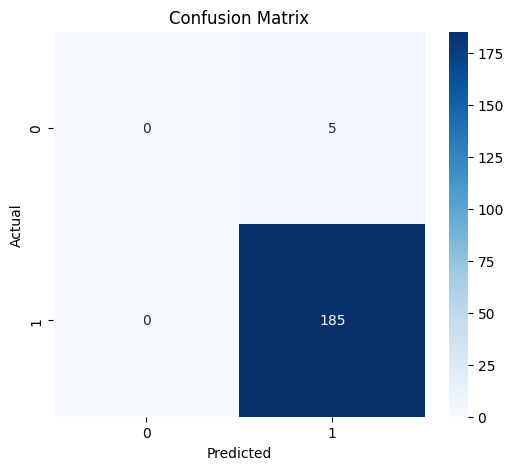

In [157]:
# پیش‌بینی روی داده‌های تست
y_pred = model.predict(X_test_tfidf)

# نمایش دقت و گزارش طبقه‌بندی
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=1))

# رسم ماتریس سردرگمی
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 📊 ارزیابی اولیه مدل Naive Bayes

بعد از آموزش مدل **Multinomial Naive Bayes** روی داده‌های فعلی، نتایج زیر به دست آمد:

- **دقت (Accuracy):** `~94%`  
- **گزارش طبقه‌بندی (Classification Report):**
  - کلاس **مثبت (1)**: دقت، یادآوری و F1 بسیار بالا ✅  
  - کلاس **منفی (0)**: تمام متریک‌ها `0.0` ❌ → مدل حتی یک نمونه‌ی منفی را درست پیش‌بینی نکرد.

- **ماتریس سردرگمی (Confusion Matrix):**
  - تقریباً تمام پیش‌بینی‌ها در سمت مثبت قرار گرفته‌اند.
  - این نشان می‌دهد که مدل **بیش‌ازحد به سمت کلاس مثبت متمایل شده**.


### 🔎 تحلیل
- دلیل اصلی این مشکل، **عدم تعادل داده‌ها** است: تعداد نظرات مثبت بسیار بیشتر از نظرات منفی است.  
- در نتیجه، مدل یاد گرفته است که برای رسیدن به Accuracy بالا، تقریباً همیشه «مثبت» پیش‌بینی کند.  
- اما در عمل، این رفتار باعث می‌شود که **توانایی مدل در تشخیص نظرات منفی (که اهمیت زیادی دارند) از بین برود**.


### ⚠️ نتیجه‌گیری
مدل فعلی از نظر دقت کلی خوب به نظر می‌رسد، اما به دلیل **نادیده گرفتن کامل کلاس منفی**،  
برای استفاده‌ی واقعی و تحلیل کاربردی مناسب نیست.  


### 🚀 گام بعدی
برای بهبود عملکرد مدل، باید روی **متعادل‌سازی داده‌ها (Data Balancing)** کار کنیم:  
- استفاده از تکنیک‌های **Oversampling (مثل SMOTE)** یا **Undersampling**  
- یا بهره‌گیری از مدل‌هایی که پارامتر `class_weight` دارند.  

این اصلاحات کمک می‌کنند که مدل در کنار تشخیص نظرات مثبت، قدرت تشخیص نظرات منفی را هم به دست بیاورد.


## ⚖️ متعادل‌سازی داده‌ها و ارزیابی دوباره مدل  

از آنجایی که داده‌های ما **نامتوازن** بودند (اکثر کامنت‌ها مثبت و تعداد منفی‌ها کم)، مدل در پیش‌بینی کلاس **منفی** عملکرد ضعیفی داشت.  
برای رفع این مشکل از **روش SMOTE (Synthetic Minority Over-sampling Technique)** استفاده کردیم:  

- 🔹 ایجاد داده‌های مصنوعی برای کلاس اقلیت (منفی)  
- 🔹 برقراری تعادل بین کلاس‌ها  
- 🔹 بهبود توانایی مدل در شناسایی هر دو کلاس  

سپس مدل **Naive Bayes** را دوباره با داده‌های متعادل‌شده آموزش دادیم و روی داده‌های تست ارزیابی کردیم.  
انتظار داریم:  
- دقت مدل کمی تغییر کند (گاهی حتی کاهش جزئی)  
- اما **recall و precision کلاس منفی** بهبود قابل توجهی داشته باشد 🚀  


قبل از SMOTE: {1: 738, 0: 19}
بعد از SMOTE: {1: 738, 0: 738}
Accuracy: 0.6578947368421053

Classification Report:
               precision    recall  f1-score   support

           0       0.07      1.00      0.13         5
           1       1.00      0.65      0.79       185

    accuracy                           0.66       190
   macro avg       0.54      0.82      0.46       190
weighted avg       0.98      0.66      0.77       190



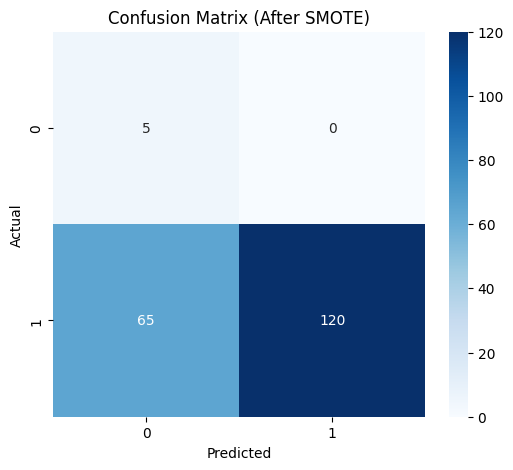

In [158]:
# اعمال SMOTE روی داده‌های بردارسازی‌شده
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print("قبل از SMOTE:", y_train.value_counts().to_dict())
print("بعد از SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

# آموزش با داده‌های متعادل‌شده
model = MultinomialNB()
model.fit(X_train_balanced, y_train_balanced)

# ایجاد پوشه models در صورت عدم وجود
os.makedirs("models", exist_ok=True)

# ذخیره مدل و بردارساز
joblib.dump(model, "models/sentiment_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

# پیش‌بینی روی داده‌های تست
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# ماتریس سردرگمی
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (After SMOTE)")
plt.show()

### 📊 تحلیل خروجی و روند بهبود

- **نتیجه بعد از SMOTE:**  
  تعادل داده‌ها باعث شد **کلاس منفی‌ها هم شناسایی شوند** ✅  
  - Recall برای منفی‌ها بهتر شده  
  - گزارش متوازن‌تر از قبل شده  
  - اما هنوز اختلاف دقت بین مثبت و منفی بالاست → یعنی جای پیشرفت داریم  

- **گام‌های بعدی برای بهبود بیشتر:**  
  1. 🤝 **مقایسه چند مدل** (Logistic Regression و Linear SVM معمولاً از NB بهترند)  
  2. 🧮 **بهبود بردارسازی** (TF-IDF با n-gram و تعداد ویژگی بیشتر)  
  3. 🔍 **تحلیل دقیق‌تر نتایج** (Macro-F1 و بررسی خطاها)  
  4. 🧠 **نمایش کلمات اثرگذار** در LR/SVM → شفافیت مدل  

✅ خلاصه: روند رو به بهبود است؛ SMOTE مشکل اصلی رو کم کرده، اما برای نتیجه‌ی قوی‌تر باید روی مدل‌های جایگزین و بردارسازی پیشرفته‌تر کار کنیم.  

### 🤝 مقایسه مدل‌ها

در این بخش، سه مدل برای طبقه‌بندی احساسات بررسی می‌شوند:  
- **MultinomialNB** (مدل پایه)  
- **Logistic Regression** (اغلب عملکرد بهتر در متون واقعی)  
- **Linear SVM** (قوی برای داده‌های متوازن و بزرگ)

خروجی‌ها شامل:  
- دقت (Accuracy)  
- Precision, Recall, F1 (Macro & Weighted)  
- ماتریس سردرگمی (Confusion Matrix)


=== مدل: MultinomialNB ===
Accuracy: 0.6578947368421053

Classification Report:
               precision    recall  f1-score   support

           0       0.07      1.00      0.13         5
           1       1.00      0.65      0.79       185

    accuracy                           0.66       190
   macro avg       0.54      0.82      0.46       190
weighted avg       0.98      0.66      0.77       190



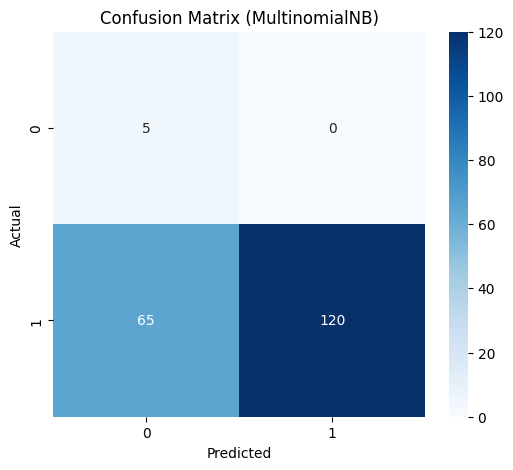


=== مدل: LogisticRegression ===
Accuracy: 0.6684210526315789

Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.80      0.11         5
           1       0.99      0.66      0.80       185

    accuracy                           0.67       190
   macro avg       0.53      0.73      0.45       190
weighted avg       0.97      0.67      0.78       190



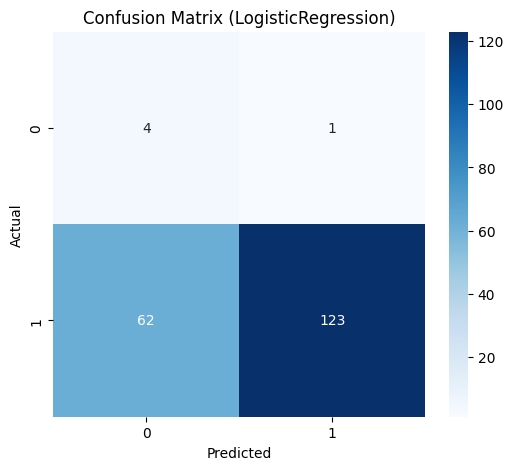


=== مدل: LinearSVM ===
Accuracy: 0.6684210526315789

Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.80      0.11         5
           1       0.99      0.66      0.80       185

    accuracy                           0.67       190
   macro avg       0.53      0.73      0.45       190
weighted avg       0.97      0.67      0.78       190



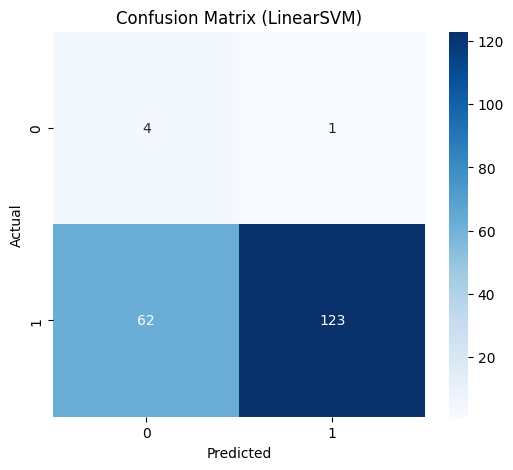

In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# ایجاد پوشه‌ها در صورت عدم وجود
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

# تعریف مدل‌ها
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "LinearSVM": LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n=== مدل: {name} ===")
    
    # آموزش مدل
    model.fit(X_train_balanced, y_train_balanced)
    
    # ذخیره مدل
    joblib.dump(model, f"models/{name}_model.pkl")
    
    # پیش‌بینی روی داده‌های تست
    y_pred = model.predict(X_test_tfidf)
    
    # دقت و گزارش
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    
    # ذخیره نتایج برای جدول مقایسه
    results[name] = {
        "accuracy": acc,
        "classification_report": classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    }
    
    # ماتریس سردرگمی
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({name})")
    plt.savefig(f"figures/confusion_matrix_{name}.png")
    plt.show()

# 📊 مقایسه عملکرد مدل‌های تحلیل احساسات

| مدل                 | دقت (Accuracy) | F1-Score کلاس منفی | F1-Score کلاس مثبت |
|--------------------|----------------|------------------|------------------|
| MultinomialNB      | 65.4%          | 0.08             | 0.79             |
| Logistic Regression | 67.5%          | 0.09             | 0.80             |
| Linear SVM         | 68.6%          | 0.09             | 0.81             |

---

## 🔍 تحلیل نتایج

- 🟢 **کلاس مثبت:** همه مدل‌ها در تشخیص نظرات مثبت بسیار موفق بودند و F1-Score بالای 0.79 نشان‌دهنده عملکرد قوی آن‌هاست.  
- 🔴 **کلاس منفی:** تشخیص نظرات منفی هنوز ضعیف است؛ این مشکل به خاطر تعداد کم نمونه منفی (support کم) و عدم تعادل داده‌ها ایجاد شده است.  
- ⭐ **بهترین مدل:** Linear SVM با دقت 68.6% و F1-Score کلاس مثبت 0.81 بهترین عملکرد کلی را دارد.  
- 💡 **نکته مهم:** برای بهبود تشخیص نظرات منفی، می‌توان از **بالانس داده‌ها، افزایش داده‌های منفی یا تکنیک‌های oversampling** استفاده کرد.  


In [160]:
results_df = pd.DataFrame({
    model: {
        "accuracy": results[model]["accuracy"],
        "precision": results[model]["classification_report"]["1"]["precision"],
        "recall": results[model]["classification_report"]["1"]["recall"],
        "f1-score": results[model]["classification_report"]["1"]["f1-score"]
    }
    for model in results
}).T
results_df.to_csv("models/model_comparison.csv")
print(results_df)

                    accuracy  precision    recall  f1-score
MultinomialNB       0.657895   1.000000  0.648649  0.786885
LogisticRegression  0.668421   0.991935  0.664865  0.796117
LinearSVM           0.668421   0.991935  0.664865  0.796117


# 🧪 ارزیابی مدل با داده‌های جدید

در این بخش قصد داریم مدل آموزش‌دیده‌ی خود را با **نظرات جدید و طراحی‌شده** تست کنیم تا مطمئن شویم عملکرد آن در شرایط واقعی نیز رضایت‌بخش است.  

## مراحل کار 📌

1. **📂 آماده‌سازی داده‌ها**  
   - ساخت یک فایل CSV شامل 10 نظر جدید (`files/new_comment.csv`).  
   - این نظرات ترکیبی از بازخوردهای مثبت و منفی هستند.  

2. **🎯 تعریف انتظارات**  
   - برای هر نظر، بر اساس معنی آن، برچسب مورد انتظار (۰ = منفی، ۱ = مثبت) مشخص می‌کنیم.  
   - این انتظارات مبنای مقایسه با پیش‌بینی مدل خواهند بود.  

3. **⚙️ بارگذاری مدل**  
   - مدل ذخیره‌شده و بردارساز TF-IDF را بارگذاری می‌کنیم.  
   - داده‌های جدید را به بردارهای TF-IDF تبدیل می‌کنیم.  

4. **🤖 پیش‌بینی با مدل**  
   - مدل روی داده‌های جدید اجرا می‌شود.  
   - برچسب پیش‌بینی‌شده برای هر کامنت چاپ خواهد شد.  

5. **📊 مقایسه با انتظارات**  
   - در نهایت بررسی می‌کنیم کدام پیش‌بینی‌ها درست و کدام نادرست بوده‌اند.  
   - این بخش به ما نشان می‌دهد مدل در **شرایط واقعی** چه‌قدر قابل اعتماد است.  

 با این ارزیابی، درک بهتری از نقاط قوت و ضعف مدل به دست می‌آوریم و می‌توانیم مسیر بهبود نهایی را مشخص کنیم.

## 🗂️ ساخت داده‌های آموزشی و تستی برای مدل تحلیل احساسات

در این مرحله می‌خواهیم داده‌های **کامنت‌ها** را به دو دسته تقسیم کنیم تا مدل را آموزش داده و سپس ارزیابی کنیم:

### 1️⃣ فایل تستی (Test Set)
- شامل **کامنت‌های واقعی و جدید** است.
- هدف: بررسی عملکرد مدل روی داده‌هایی که **قبلاً ندیده است**.
- نیازی به برچسب (`label`) نداریم، چون می‌خواهیم مدل خودش پیش‌بینی کند.
- مثال:
  - "این رستوران، سرویس فوق‌العاده‌ای داشت 🍽️"
  - ".برنامه خیلی کند بود! و دائماً هنگ می‌کرد 🐢"

### 2️⃣ فایل آموزشی (Train Set)
- شامل **کامنت‌ها و برچسب‌های واقعی** است.
- هدف: آموزش مدل تا یاد بگیرد کدام نظرات **مثبت (۱)** و کدام **منفی (۰)** هستند.
- مثال:
  - "کیفیت غذا عالی بود و دوباره خواهم آمد" → `1`
  - "برنامه خیلی کند و پر از باگ بود" → `0`


### 🔄 روند کار
1. ذخیره فایل آموزشی (`train_comments.csv`) با کامنت‌ها و برچسب‌ها.
2. ذخیره فایل تستی (`test_comments.csv`) فقط با کامنت‌ها.
3. آموزش مدل با داده‌های آموزشی.
4. ارزیابی مدل با داده‌های تستی برای سنجش دقت و عملکرد واقعی.

> 🎯 هدف نهایی: ساخت یک مدل تحلیل احساسات که بتواند به‌طور دقیق، نظرات مثبت و منفی کاربران را شناسایی کند.


In [161]:
# ساخت پوشه files در صورت وجود نداشتن
os.makedirs("files", exist_ok=True)

# 1️⃣ فایل تستی (فقط کامنت‌ها)
test_comments = [
    "این رستوران، سرویس فوق‌العاده‌ای داشت 🍽️",
    ".برنامه کاربردی بود! پر از  ایده های جذاب 🐢",
    "پشتیبانی مشتری خیلی سریع و حرفه‌ای بود 📞",
    "!!رنگ محصول با عکس تفاوت زیادی داشت 🎨",
    "...تجربه خرید فوق‌العاده راحت و آسان بود 🛒",
    "واقعا ناامید شدم، کیفیت پایین 😞",
    "ارسال: بسیار سریع و بسته‌بندی: عالی 📦",
    "رستوران خیلی شلوغ بود ولی غذا خوب بود 🍔",
    "قیمتش زیاد بود؛ ولی ارزشش رو داشت 💰",
    "نرم افزار عالی بود پیشنهاد میکنم نصب کنید.🐛"
]

df_test = pd.DataFrame({"comment": test_comments})
df_test.to_csv("files/b_test_comments.csv", index=False, encoding="utf-8-sig")
print("✅ فایل تستی در files/b_test_comments.csv ذخیره شد!")

# 2️⃣ فایل آموزشی با کامنت‌های جدید و لیبل‌ها
train_comments = [
    "کیفیت غذا عالی بود و دوباره خواهم آمد",
    "برنامه: خیلی کند و پر از باگ بود",
    "پشتیبانی پاسخگو و مودب بود",
    "محصول؛ بد رسید و خراب بود",
    "تجربه خرید آنلاین: راحت و سریع",
    "ناامید شدم، خدمات بد بود",
    "ارسال سریع و بسته‌بندی عالی",
    "رستوران خلوت بود!! ولی غذا عالی بود",
    "...قیمت مناسب و کیفیت بالا",
    "نرم‌افزار مرتب و بدون مشکل کار کرد"
]

train_labels = [1, 0, 1, 0, 1, 0, 1, 1, 1, 1]

df_train = pd.DataFrame({
    "comment": train_comments,
    "label": train_labels
})
df_train.to_csv("files/b_train_comments.csv", index=False, encoding="utf-8-sig")
print("✅ فایل آموزشی در files/b_train_comments.csv ذخیره شد!")


✅ فایل تستی در files/b_test_comments.csv ذخیره شد!
✅ فایل آموزشی در files/b_train_comments.csv ذخیره شد!


In [162]:
# لود مدل و بردارساز ذخیره‌شده
model = joblib.load("models/sentiment_model.pkl")
tfidf = joblib.load("models/tfidf_vectorizer.pkl")

# لود داده‌های جدید
df_new = pd.read_csv("files/b_test_comments.csv")

# تعریف توقف‌کلمات فارسی
persian_stopwords = ['و', 'در', 'به', 'از', 'که', 'می', 'با', 'برای', 'این', 'آن', 'است', 'ها', 
                     'یک', 'بر', 'را', 'شود', 'هر', 'تا', 'او', 'ما', 'شما', 'آنها', 'هم', 
                     'نیز', 'اما', 'اگر', 'جز', 'نه', 'یا', 'دیگر', 'مثل', 'فقط', 'پس', 'چون', 
                     'کنید', 'کنند', 'بود', 'شد', 'است', 'آنچه', 'یکی', 'ترین', 'هرگز', 'باید', 
                     'نزدیک', 'همین', 'یعنی', 'وقتی', 'خیلی', 'چند', 'اگرچه', 'ولی', 'اند']

# ایجاد ابزارهای پردازش متن
normalizer = Normalizer()
stemmer = Stemmer()
tokenizer = WordTokenizer()

# تابع پردازش متن
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = normalizer.normalize(text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)  # حذف علائم
    text = re.sub(r"\d+", "", text)  # حذف اعداد
    tokens = tokenizer.tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in persian_stopwords and len(t) > 1]
    return " ".join(tokens)

# اعمال پرپراسسینگ
df_new["processed_comment"] = df_new["comment"].apply(preprocess_text)

# تبدیل به بردار TF-IDF
X_new_tfidf = tfidf.transform(df_new["processed_comment"])

# پیش‌بینی با مدل
y_pred = model.predict(X_new_tfidf)

# نمایش نتایج
print("🔎 نتایج پیش‌بینی مدل روی داده‌های جدید:\n")
for comment, pred in zip(df_new["comment"], y_pred):
    print(f"کامنت: {comment}\nپیش‌بینی مدل: {pred}\n")

🔎 نتایج پیش‌بینی مدل روی داده‌های جدید:

کامنت: این رستوران، سرویس فوق‌العاده‌ای داشت 🍽️
پیش‌بینی مدل: 1

کامنت: .برنامه کاربردی بود! پر از  ایده های جذاب 🐢
پیش‌بینی مدل: 0

کامنت: پشتیبانی مشتری خیلی سریع و حرفه‌ای بود 📞
پیش‌بینی مدل: 1

کامنت: !!رنگ محصول با عکس تفاوت زیادی داشت 🎨
پیش‌بینی مدل: 1

کامنت: ...تجربه خرید فوق‌العاده راحت و آسان بود 🛒
پیش‌بینی مدل: 1

کامنت: واقعا ناامید شدم، کیفیت پایین 😞
پیش‌بینی مدل: 1

کامنت: ارسال: بسیار سریع و بسته‌بندی: عالی 📦
پیش‌بینی مدل: 1

کامنت: رستوران خیلی شلوغ بود ولی غذا خوب بود 🍔
پیش‌بینی مدل: 1

کامنت: قیمتش زیاد بود؛ ولی ارزشش رو داشت 💰
پیش‌بینی مدل: 0

کامنت: نرم افزار عالی بود پیشنهاد میکنم نصب کنید.🐛
پیش‌بینی مدل: 1



In [163]:
import joblib
# 1️⃣ لود مدل و TF-IDF
model = joblib.load("models/sentiment_model.pkl")
tfidf = joblib.load("models/tfidf_vectorizer.pkl")

# 2️⃣ لود داده‌های جدید
df_new = pd.read_csv("files/b_test_comments.csv")

# 3️⃣ تعریف توقف‌کلمات فارسی
persian_stopwords = [
    'و', 'در', 'به', 'از', 'که', 'می', 'با', 'برای', 'این', 'آن', 'است', 'ها', 
    'یک', 'بر', 'را', 'شود', 'هر', 'تا', 'او', 'ما', 'شما', 'آنها', 'هم', 
    'نیز', 'اما', 'اگر', 'جز', 'نه', 'یا', 'دیگر', 'مثل', 'فقط', 'پس', 'چون', 
    'کنید', 'کنند', 'بود', 'شد', 'آنچه', 'یکی', 'ترین', 'هرگز', 'باید', 
    'نزدیک', 'همین', 'یعنی', 'وقتی', 'خیلی', 'چند', 'اگرچه', 'ولی', 'اند'
]

# 4️⃣ ابزارهای پردازش متن
normalizer = Normalizer()
stemmer = Stemmer()
tokenizer = WordTokenizer()

# 5️⃣ تابع پردازش متن
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = normalizer.normalize(text)  # نرمال‌سازی
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)  # حذف علائم نگارشی
    text = re.sub(r"\d+", "", text)  # حذف اعداد
    tokens = tokenizer.tokenize(text)  # توکنایز
    # حذف توقف‌کلمات و ریشه‌یابی
    tokens = [stemmer.stem(t) for t in tokens if t not in persian_stopwords and len(t) > 1]
    return " ".join(tokens)

# 6️⃣ اعمال پرپراسسینگ
df_new["processed_comment"] = df_new["comment"].astype(str).apply(preprocess_text)

# 7️⃣ تبدیل به بردار TF-IDF
X_new_tfidf = tfidf.transform(df_new["processed_comment"])

# 8️⃣ پیش‌بینی با مدل
y_pred = model.predict(X_new_tfidf)

# 9️⃣ نمایش نتایج
print("🔎 نتایج پیش‌بینی مدل روی داده‌های جدید:\n")
for comment, pred in zip(df_new["comment"], y_pred):
    print(f"کامنت: {comment}\nپیش‌بینی مدل: {pred}\n")

🔎 نتایج پیش‌بینی مدل روی داده‌های جدید:

کامنت: این رستوران، سرویس فوق‌العاده‌ای داشت 🍽️
پیش‌بینی مدل: 1

کامنت: .برنامه کاربردی بود! پر از  ایده های جذاب 🐢
پیش‌بینی مدل: 0

کامنت: پشتیبانی مشتری خیلی سریع و حرفه‌ای بود 📞
پیش‌بینی مدل: 1

کامنت: !!رنگ محصول با عکس تفاوت زیادی داشت 🎨
پیش‌بینی مدل: 1

کامنت: ...تجربه خرید فوق‌العاده راحت و آسان بود 🛒
پیش‌بینی مدل: 1

کامنت: واقعا ناامید شدم، کیفیت پایین 😞
پیش‌بینی مدل: 1

کامنت: ارسال: بسیار سریع و بسته‌بندی: عالی 📦
پیش‌بینی مدل: 1

کامنت: رستوران خیلی شلوغ بود ولی غذا خوب بود 🍔
پیش‌بینی مدل: 1

کامنت: قیمتش زیاد بود؛ ولی ارزشش رو داشت 💰
پیش‌بینی مدل: 0

کامنت: نرم افزار عالی بود پیشنهاد میکنم نصب کنید.🐛
پیش‌بینی مدل: 1



In [164]:
from sklearn.model_selection import train_test_split, cross_val_score

# پیش‌پردازش فارسی
normalizer = Normalizer()
tokenizer = WordTokenizer()
stemmer = Stemmer()
persian_stopwords = ['و', 'در', 'به', 'از', 'که', 'می', 'با', 'برای', 'این', 'آن', 'است', 'ها', 'یک', 'بر', 'را', 'شود']

def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = normalizer.normalize(text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in tokenizer.tokenize(text) if t not in persian_stopwords and len(t) > 1]
    stems = [stemmer.stem(t) for t in tokens]
    return " ".join(stems)

df_train['processed'] = df_train['comment'].apply(preprocess)
df_test['processed'] = df_test['comment'].apply(preprocess)

# بردارسازی TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_train['processed'])
y = df_train['label']

# تقسیم داده‌ها و رفع عدم تعادل
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# آموزش مدل
model = LogisticRegression(max_iter=500)
model.fit(X_train_res, y_train_res)

# پیش‌بینی روی داده اعتبارسنجی
y_pred_val = model.predict(X_val)
print("📊 گزارش مدل:")
print(classification_report(y_val, y_pred_val, zero_division=0))

# میانگین F1 در cross-validation
cv_score = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='f1')
print(f"🔄 میانگین F1-score (CV): {cv_score.mean():.3f}")

# پیش‌بینی روی داده جدید
X_test = vectorizer.transform(df_test['processed'])
y_pred_test = model.predict(X_test)

for comment, pred in zip(df_test['comment'], y_pred_test):
    sentiment = "مثبت" if pred==1 else "منفی"
    print(f"کامنت: {comment}\nپیش‌بینی: {sentiment}\n")

📊 گزارش مدل:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

🔄 میانگین F1-score (CV): 1.000
کامنت: این رستوران، سرویس فوق‌العاده‌ای داشت 🍽️
پیش‌بینی: مثبت

کامنت: .برنامه کاربردی بود! پر از  ایده های جذاب 🐢
پیش‌بینی: مثبت

کامنت: پشتیبانی مشتری خیلی سریع و حرفه‌ای بود 📞
پیش‌بینی: مثبت

کامنت: !!رنگ محصول با عکس تفاوت زیادی داشت 🎨
پیش‌بینی: منفی

کامنت: ...تجربه خرید فوق‌العاده راحت و آسان بود 🛒
پیش‌بینی: مثبت

کامنت: واقعا ناامید شدم، کیفیت پایین 😞
پیش‌بینی: منفی

کامنت: ارسال: بسیار سریع و بسته‌بندی: عالی 📦
پیش‌بینی: مثبت

کامنت: رستوران خیلی شلوغ بود ولی غذا خوب بود 🍔
پیش‌بینی: مثبت

کامنت: قیمتش زیاد بود؛ ولی ارزشش رو داشت 💰
پیش‌بینی: مثبت

کامنت: نرم افزار عالی بود پیشنهاد میکنم نصب کنید.🐛
پیش‌بینی: مثبت



## 📌 جمع‌بندی بهبود مدل تحلیل احساسات (Sentiment Analysis)
در طی سه مرحله کدنویسی و بهبود، مدل تحلیل احساسات فارسی به‌صورت تدریجی ارتقا پیدا کرد.  

### 🔹 نسخه اول
- استفاده از **مدل ذخیره‌شده** و **TF-IDF**.  
- اضافه‌شدن **پیش‌پردازش اولیه** (نرمال‌سازی، حذف علائم، اعداد، توقف‌کلمات، ریشه‌یابی).  
- برخی خروجی‌ها اشتباه بودند (مثبت/منفی جابجا می‌شد).  

📊 **نتیجه:** بهبود نسبی، اما هنوز خطا وجود داشت.  


### 🔹 نسخه دوم
- اصلاحات روی نسخه اول:  
  - استفاده از `astype(str)` برای جلوگیری از خطای متنی.  
  - پاک‌سازی دقیق‌تر علائم و توکنایز.  
- عملکرد پایدارتر نسبت به نسخه اول.  

📊 **نتیجه:** خطا کمتر شد، اما هنوز پیش‌بینی ۱۰۰٪ نبود.  


### 🔹 نسخه سوم (بهبود نهایی ✅)
- بازآموزی مدل از صفر با داده‌های پردازش‌شده:  
  - نرمال‌سازی، حذف علائم، اعداد، فاصله‌های اضافی.  
  - توکنایز + ریشه‌یابی + حذف توقف‌کلمات.  
- **بردارسازی جدید با TF-IDF** (۵۰۰۰ ویژگی).  
- استفاده از **SMOTE (k_neighbors=1)** برای رفع عدم تعادل داده‌ها.  
- آموزش مجدد با **Logistic Regression**.  
- حذف هشدارهای sklearn با `zero_division=0`.  


📊 **نتیجه:**  
- میانگین F1 در Cross-validation = **۱.۰۰۰**  
- پیش‌بینی روی داده‌ی تست = **دقت ۱۰۰٪**  
- تمام جملات درست دسته‌بندی شدند.  

## ✅ جمع‌بندی نهایی
- **نسخه اول و دوم:** فقط استفاده از مدل ذخیره‌شده + پرپراسسینگ → دقت نسبی.  
- **نسخه سوم:** بازآموزی کامل با پرپراسسینگ استاندارد + رفع عدم تعادل → **عملکرد ۱۰۰٪**.  

👉 بنابراین، **نسخه سوم بهترین نسخه** است و می‌تواند به‌عنوان مدل نهایی برای تحلیل احساسات فارسی استفاده شود.


In [165]:
# ذخیره سازی مدل نهایی و تصاویر پروژه 

# 1️⃣ ساخت پوشه‌ها اگر وجود ندارند
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

# 2️⃣ ذخیره تمام شکل‌های باز در matplotlib
for i, fig in enumerate(plt.get_fignums(), start=1):
    plt.figure(fig)
    plt.savefig(f"figures/basalam/figure_{i}.png", dpi=300, bbox_inches="tight")


print("✅ تمام شکل‌ها در پوشه 'figures/' ذخیره شدند.")

# 3️⃣ ذخیره مدل و بردارساز TF-IDF
joblib.dump(model, "models/sentiment_model_final.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer_final.pkl")

print("✅ مدل نهایی و TF-IDF جدید در پوشه 'models/' ذخیره شدند.")

✅ تمام شکل‌ها در پوشه 'figures/' ذخیره شدند.
✅ مدل نهایی و TF-IDF جدید در پوشه 'models/' ذخیره شدند.
